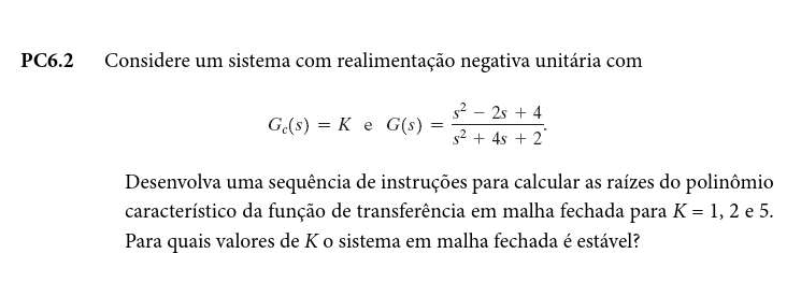

PC6.2: ANÁLISE DE ESTABILIDADE - RAÍZES DO POLINÔMIO CARACTERÍSTICO

Função da Planta:
G(s) = (s² - 2s + 4)/(s² + 4s + 2)
<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s^2 - 2 s + 4
  -------------
  s^2 + 4 s + 2

ANÁLISE DAS RAÍZES DO POLINÔMIO CARACTERÍSTICO

--------------------------------------------------------------------------------
CASO: K = 1
--------------------------------------------------------------------------------

Controlador: Gc(s) = 1

Função de transferência em malha fechada:
<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   s^2 - 2 s + 4
  ---------------
  2 s^2 + 2 s + 6

Polinômio característico: (2)s² + (2)s + (6) = 0
Simplificado: 2s² + 2s + 6 = 0

Raízes (Polos em malha fechada):
  Polo 1: -0.500000+1.658312j
  Polo 2: -0.500000-1.658312j

Análise de Estabilidade:
  Número de polos com parte real negativa: 2 de 2
  Sistema ESTÁVEL? SIM ✓

------------------------------------------------------------------

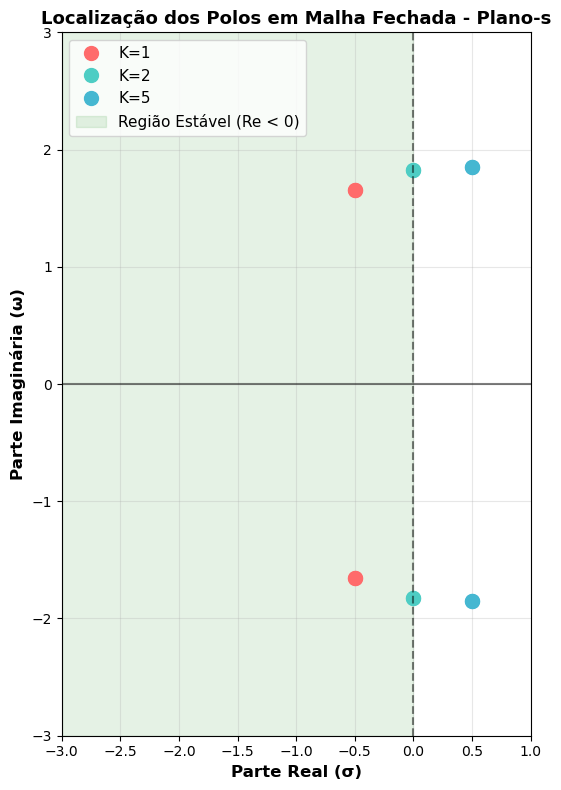


Gráfico do Plano-s gerado com sucesso!


In [1]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("PC6.2: ANÁLISE DE ESTABILIDADE - RAÍZES DO POLINÔMIO CARACTERÍSTICO")
print("=" * 80)

# Definir a variável de Laplace
s = ct.tf('s')

# Sistema com realimentação negativa unitária
# Gc(s) = K (controlador proporcional)
# G(s) = (s² - 2s + 4)/(s² + 4s + 2)

# Função da planta
numerador_G = s**2 - 2*s + 4
denominador_G = s**2 + 4*s + 2
G = numerador_G / denominador_G

print("\nFunção da Planta:")
print("G(s) = (s² - 2s + 4)/(s² + 4s + 2)")
print(G)

# Valores de K para análise
K_values = [1, 2, 5]

# Armazenar resultados
resultados = {}

print("\n" + "=" * 80)
print("ANÁLISE DAS RAÍZES DO POLINÔMIO CARACTERÍSTICO")
print("=" * 80)

for K in K_values:
    print("\n" + "-" * 80)
    print(f"CASO: K = {K}")
    print("-" * 80)
    
    # Controlador proporcional
    Gc = K
    
    # Função de transferência em malha aberta
    G_ol = Gc * G
    
    # Função de transferência em malha fechada
    # T(s) = G_ol(s) / (1 + G_ol(s))
    T = ct.feedback(G_ol)
    
    print(f"\nControlador: Gc(s) = {K}")
    print(f"\nFunção de transferência em malha fechada:")
    print(T)
    
    # Extrair polinômio característico (raízes do denominador)
    # O denominador de T(s) é: 1 + G_ol(s) = 1 + K*G(s)
    # = 1 + K*(s² - 2s + 4)/(s² + 4s + 2)
    # = [(s² + 4s + 2) + K(s² - 2s + 4)] / (s² + 4s + 2)
    # Polinômio característico: (s² + 4s + 2) + K(s² - 2s + 4) = 0
    # Reorganizando: (1 + K)s² + (4 - 2K)s + (2 + 4K) = 0
    
    # Coeficientes do polinômio característico
    a = 1 + K
    b = 4 - 2*K
    c = 2 + 4*K
    
    # Calcular raízes
    raizes = np.roots([a, b, c])
    
    print(f"\nPolinômio característico: ({a})s² + ({b})s + ({c}) = 0")
    print(f"Simplificado: {a}s² + {b}s + {c} = 0")
    
    print("\nRaízes (Polos em malha fechada):")
    polos_estáveis = 0
    for i, raiz in enumerate(raizes):
        if np.isreal(raiz):
            raiz_val = np.real(raiz)
            print(f"  Polo {i+1}: {raiz_val:.6f} (Real)")
            if raiz_val < 0:
                polos_estáveis += 1
        else:
            print(f"  Polo {i+1}: {raiz:.6f}")
            if np.real(raiz) < 0:
                polos_estáveis += 1
    
    # Verificar estabilidade
    is_stable = np.all(np.real(raizes) < 0)
    
    print(f"\nAnálise de Estabilidade:")
    print(f"  Número de polos com parte real negativa: {polos_estáveis} de {len(raizes)}")
    print(f"  Sistema ESTÁVEL? {'SIM ✓' if is_stable else 'NÃO ✗'}")
    
    # Armazenar resultados
    resultados[K] = {
        'raizes': raizes,
        'estável': is_stable,
        'polinômio': [a, b, c]
    }

print("\n" + "=" * 80)
print("RESUMO COMPARATIVO")
print("=" * 80)

print("\n{:<10} | {:<15} | {:<30} | {:<12}".format("K", "Polinômio", "Raízes", "Estável?"))
print("-" * 80)

for K in K_values:
    a, b, c = resultados[K]['polinômio']
    estavel = "✓ SIM" if resultados[K]['estável'] else "✗ NÃO"
    raizes_str = ", ".join([f"{np.real(r):.3f}" if np.isreal(r) else f"{r:.3f}" 
                            for r in resultados[K]['raizes']])
    print("{:<10} | {:<15} | {:<30} | {:<12}".format(
        K, f"{a}s²+{b}s+{c}", raizes_str, estavel))

print("\n" + "=" * 80)
print("CONCLUSÕES SOBRE ESTABILIDADE")
print("=" * 80)

print("\n1. ANÁLISE POR CRITÉRIO DE ROUTH-HURWITZ:")
print("   Para o polinômio: (1+K)s² + (4-2K)s + (2+4K) = 0")
print("   Condições necessárias para estabilidade:")
print("   - (1+K) > 0  →  K > -1")
print("   - (4-2K) > 0  →  K < 2")
print("   - (2+4K) > 0  →  K > -0.5")
print("   - Determinante > 0  →  (4-2K)² - 4(1+K)(2+4K) > 0")

# Verificar as condições
print("\n2. VERIFICAÇÃO DAS CONDIÇÕES PARA CADA K:")
for K in K_values:
    print(f"\n   K = {K}:")
    cond1 = (1 + K) > 0
    cond2 = (4 - 2*K) > 0
    cond3 = (2 + 4*K) > 0
    det = (4 - 2*K)**2 - 4*(1+K)*(2+4*K)
    cond4 = det > 0
    
    print(f"   - (1+K) > 0: {1+K} > 0 → {'✓' if cond1 else '✗'}")
    print(f"   - (4-2K) > 0: {4-2*K} > 0 → {'✓' if cond2 else '✗'}")
    print(f"   - (2+4K) > 0: {2+4*K} > 0 → {'✓' if cond3 else '✗'}")
    print(f"   - Determinante: {det:.2f} > 0 → {'✓' if cond4 else '✗'}")
    print(f"   → Sistema {'ESTÁVEL' if resultados[K]['estável'] else 'INSTÁVEL'}")

# Encontrar limites de estabilidade
print("\n3. FAIXA DE ESTABILIDADE:")
print("   Intervalo de K para estabilidade: -1 < K < 2")
print("   Em termos práticos: 0 < K < 2 (K positivo)")
print("   ")
print("   Pontos críticos:")
print("   - K = -1: Polinômio degenerado (ordem reduzida)")
print("   - K = 2: Polinômio tem raízes no eixo imaginário (margem de estabilidade = 0)")
print("   - K = -0.5: Raízes tornam-se positivas")

# Plotar as raízes no plano-s
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

cores = {'#FF6B6B', '#4ECDC4', '#45B7D1'}
cores_list = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, K in enumerate(K_values):
    raizes = resultados[K]['raizes']
    estavel = resultados[K]['estável']
    
    # Plotar raízes
    for raiz in raizes:
        if np.isreal(raiz):
            ax.plot(np.real(raiz), 0, 'o', markersize=10, color=cores_list[idx], 
                   label=f'K={K}' if raiz == raizes[0] else '')
        else:
            ax.plot(np.real(raiz), np.imag(raiz), 'o', markersize=10, 
                   color=cores_list[idx], label=f'K={K}' if raiz == raizes[0] else '')
            ax.plot(np.real(raiz), -np.imag(raiz), 'o', markersize=10, color=cores_list[idx])

# Adicionar eixo imaginário
ax.axvline(x=0, color='k', linewidth=1.5, linestyle='--', alpha=0.5)
ax.axhline(y=0, color='k', linewidth=1.5, linestyle='-', alpha=0.5)

# Regiões de estabilidade
ax.fill_between([-3, 0], -3, 3, alpha=0.1, color='green', label='Região Estável (Re < 0)')

ax.set_xlabel('Parte Real (σ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Parte Imaginária (ω)', fontsize=12, fontweight='bold')
ax.set_title('Localização dos Polos em Malha Fechada - Plano-s', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(-3, 1)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("Gráfico do Plano-s gerado com sucesso!")
print("=" * 80)
